<a href="https://colab.research.google.com/github/marianafreitasc/CicloGuia---Seguran-a-Ciclovi-ria-do-Rio/blob/main/bairros_datario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('bairros_datario.csv')
df.head()

,objectid,nome,regiao_adm,area_plane,codbairro,codra,codbnum,link,rp,cod_rp,codbairro_long,st_areashape,st_perimetershape
0,325,Paquetá,PAQUETA,1,13,21,13,Paqueta&area=013 ...,Centro,1.1,13,1.705689e+06,24841.459984
1,326,Freguesia (Ilha),ILHA DO GOVERNADOR,3,98,20,98,Freguesia (Ilha) &area=98 ...,Ilha do Governador,3.7,98,4.056414e+06,18303.621385
2,327,Bancários,ILHA DO GOVERNADOR,3,97,20,97,Bancários &area=97 ...,Ilha do Governador,3.7,97,9.780492e+05,7758.791895
3,328,Galeão,ILHA DO GOVERNADOR,3,104,20,104,Galeão &area=104 ...,Ilha do Governador,3.7,104,1.895747e+07,21510.088396
4,329,Tauá,ILHA DO GOVERNADOR,3,101,20,101,Tauá &area=101 ...,Ilha do Governador,3.7,101,1.672550e+06,8246.120720


In [ ]:
#dimensões do dataser
df.shape

(166, 13)

In [ ]:
#tipos de dados e informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   objectid           166 non-null    int64  
 1   nome               166 non-null    object 
 2   regiao_adm         166 non-null    object 
 3   area_plane         166 non-null    int64  
 4   codbairro          166 non-null    int64  
 5   codra              166 non-null    int64  
 6   codbnum            166 non-null    int64  
 7   link               166 non-null    object 
 8   rp                 166 non-null    object 
 9   cod_rp             166 non-null    float64
 10  codbairro_long     166 non-null    int64  
 11  st_areashape       166 non-null    float64
 12  st_perimetershape  166 non-null    float64
dtypes: float64(3), int64(6), object(4)
memory usage: 17.0+ KB


In [ ]:
#estatísticas descritivas das variáveis numéricas
df.describe()

,objectid,area_plane,codbairro,codra,codbnum,cod_rp,codbairro_long,st_areashape,st_perimetershape
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,1.660000e+02,166.000000
mean,439.873494,3.066265,83.500000,15.710843,83.500000,3.338554,83.500000,7.253920e+06,13156.494491
std,126.334293,1.112657,48.064193,8.082199,48.064193,1.145143,48.064193,1.771599e+07,12919.857230
min,325.000000,1.000000,1.000000,1.000000,1.000000,1.100000,1.000000,3.176863e+04,1076.305055
25%,374.250000,3.000000,42.250000,10.250000,42.250000,3.100000,42.250000,1.327435e+06,6482.989371
50%,415.500000,3.000000,83.500000,15.000000,83.500000,3.400000,83.500000,2.556977e+06,9042.417717
75%,456.750000,4.000000,124.750000,20.000000,124.750000,4.100000,124.750000,4.849096e+06,14136.164184
max,909.000000,5.000000,166.000000,34.000000,166.000000,5.400000,166.000000,1.317869e+08,88693.995709


In [ ]:
#verificar se tem dados nulos
df.isnull().sum()

,0
objectid,0
nome,0
regiao_adm,0
area_plane,0
codbairro,0
codra,0
codbnum,0
link,0
rp,0
cod_rp,0


Esse dataset contém informações geográficas e administrativas dos 166 bairros oficiais do Rio e não possui nenhum valor nulo. Pelo df.describe() notamos que a área e o perímetro tem uma dispersão muito grande, a diferença entre o menor e o maior bairro é enorma o que sugere existência de outliers no dataset

###Analise Univariada

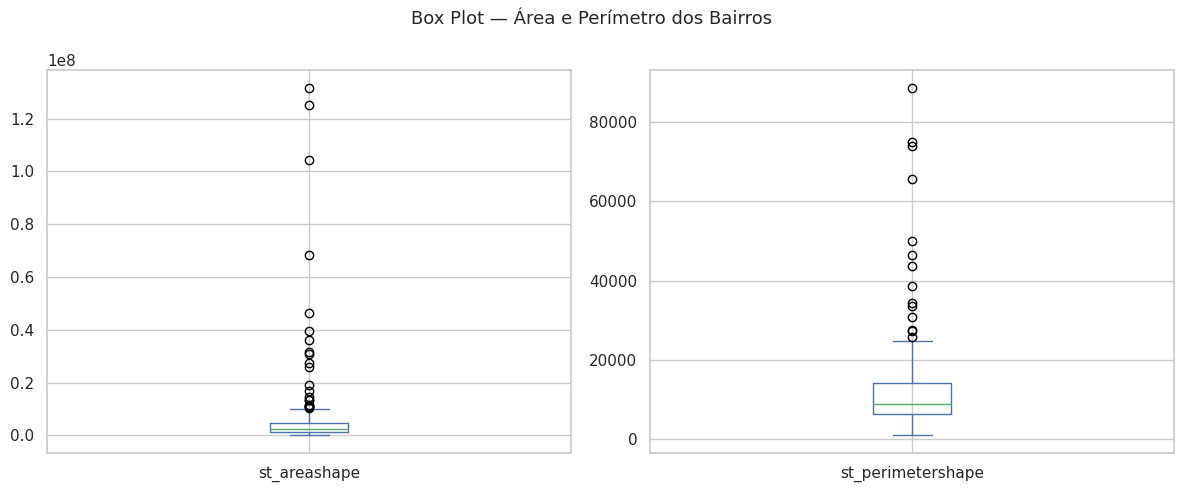

In [ ]:
# Box plot das variáveis numéricas
num_cols = ['st_areashape', 'st_perimetershape']
df[num_cols].plot(kind='box', figsize=(12, 5), subplots=True, layout=(1, 2))
plt.suptitle('Box Plot — Área e Perímetro dos Bairros', fontsize=13)
plt.tight_layout()
plt.show()

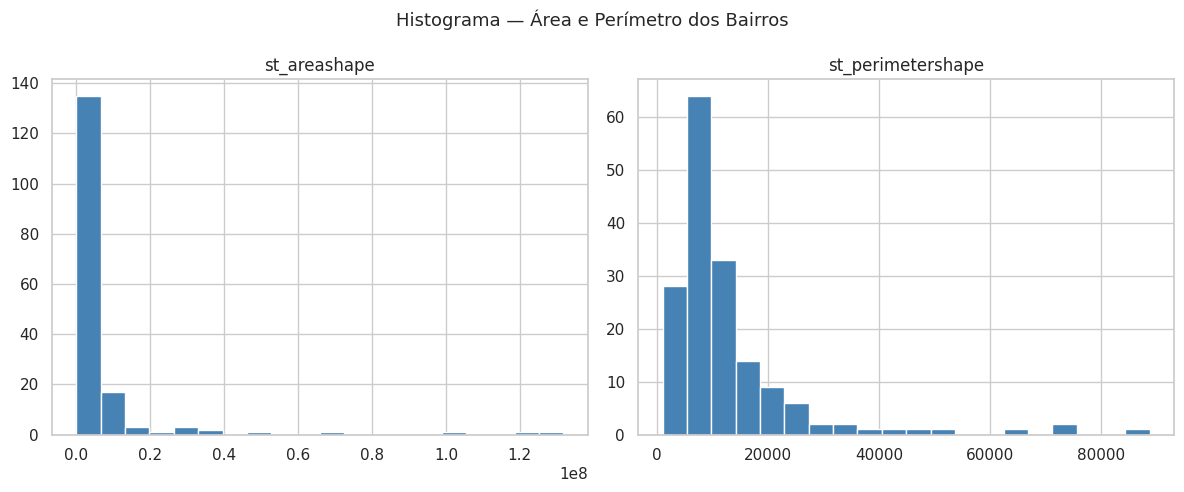

In [ ]:
# Histograma das variáveis numéricas
df[num_cols].hist(figsize=(12, 5), layout=(1, 2), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Histograma — Área e Perímetro dos Bairros', fontsize=13)
plt.tight_layout()
plt.show()

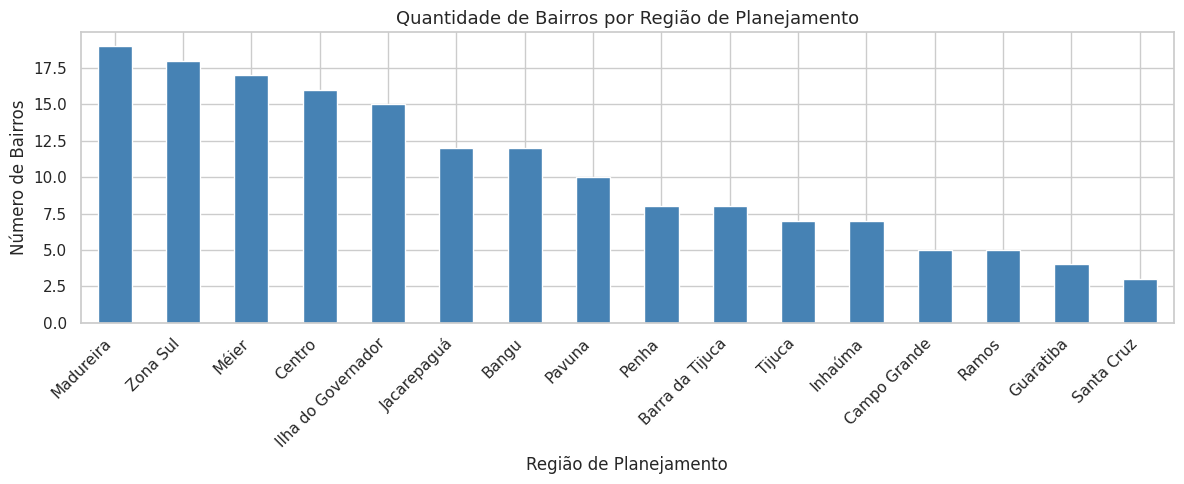

In [ ]:
# Gráfico de barras — bairros por RP
df['rp'].value_counts().plot(kind='bar', figsize=(12, 5), color='steelblue', edgecolor='white')
plt.title('Quantidade de Bairros por Região de Planejamento', fontsize=13)
plt.xlabel('Região de Planejamento')
plt.ylabel('Número de Bairros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

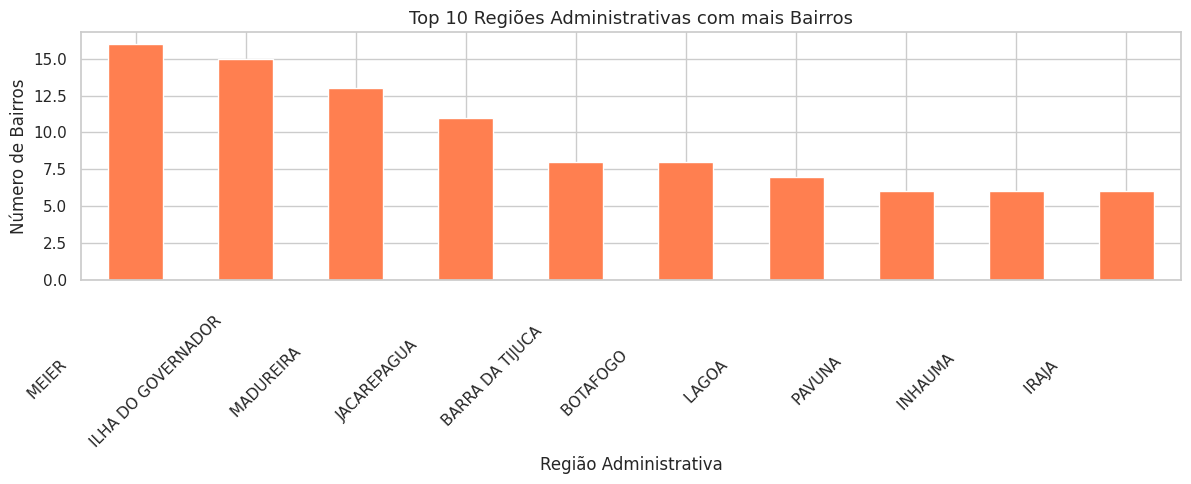

In [ ]:
# Gráfico de barras — top 10 RAs
df['regiao_adm'].value_counts().head(10).plot(kind='bar', figsize=(12, 5), color='coral', edgecolor='white')
plt.title('Top 10 Regiões Administrativas com mais Bairros', fontsize=13)
plt.xlabel('Região Administrativa')
plt.ylabel('Número de Bairros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Pelo boxplot e histograma vemos uma grande assimetria à direita, a maior parte dos bairros tem uma área e perímetro pequenos e alguns poucos do oeste puxam a média para cima. Vemos no gráfico de barras que Madureira, Meier e zona sul concentram o maior número de bairros enquanto outras regiões tem menos bairros porem um maior território

###Analise Multivariada

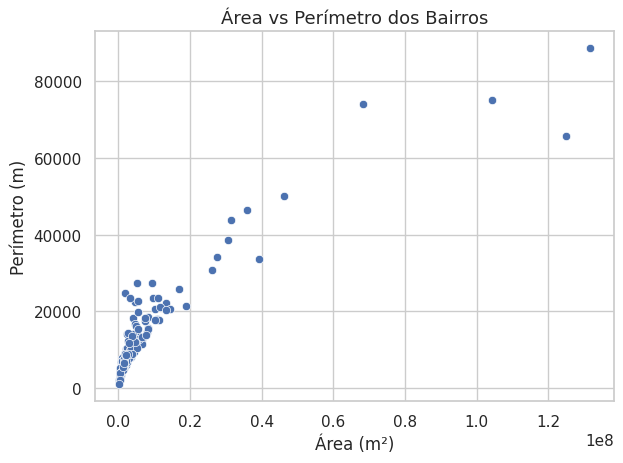

In [ ]:
# Relação entre área e perímetro dos bairros
sns.scatterplot(x='st_areashape', y='st_perimetershape', data=df)
plt.title('Área vs Perímetro dos Bairros', fontsize=13)
plt.xlabel('Área (m²)')
plt.ylabel('Perímetro (m)')
plt.tight_layout()
plt.show()

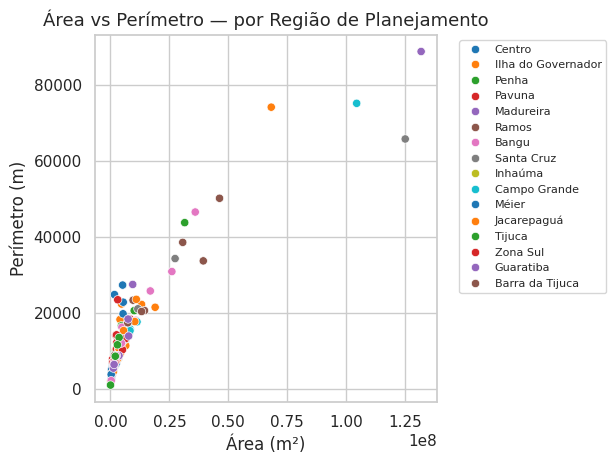

In [ ]:
# Scatter plot colorido por Região de Planejamento
sns.scatterplot(x='st_areashape', y='st_perimetershape', hue='rp', data=df, palette='tab10')
plt.title('Área vs Perímetro — por Região de Planejamento', fontsize=13)
plt.xlabel('Área (m²)')
plt.ylabel('Perímetro (m)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10553/2711736714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rp', y='st_areashape', data=df, palette='pastel')


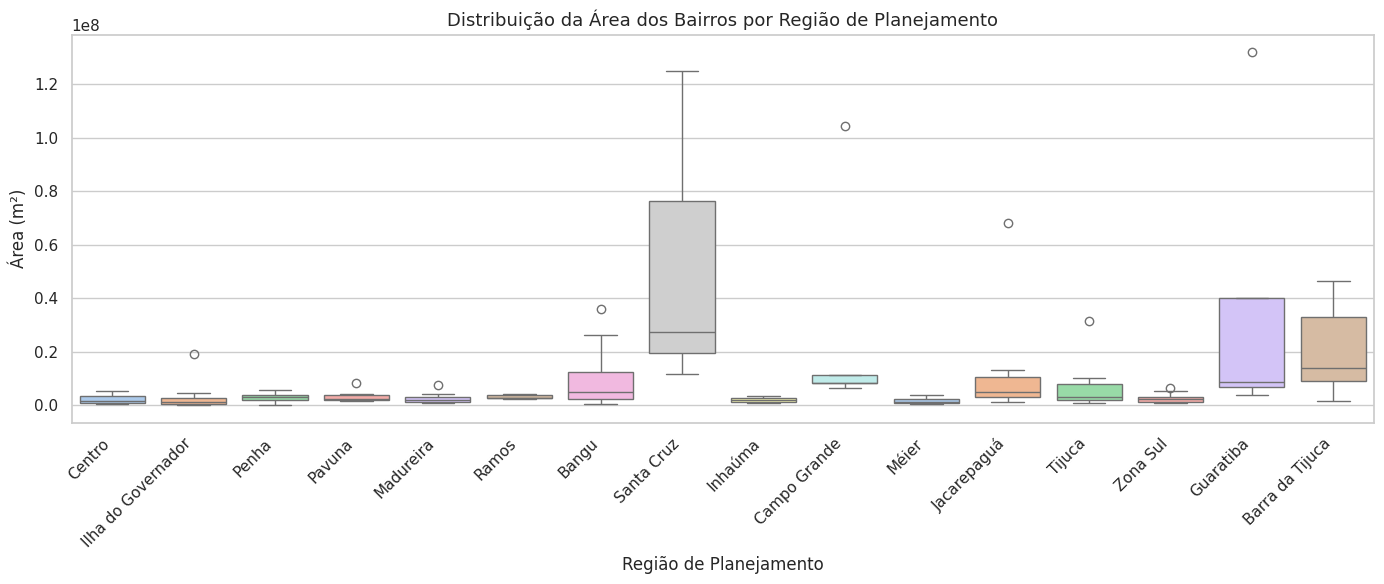

In [ ]:
# Área dos bairros por Região de Planejamento em boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(x='rp', y='st_areashape', data=df, palette='pastel')
plt.title('Distribuição da Área dos Bairros por Região de Planejamento', fontsize=13)
plt.xlabel('Região de Planejamento')
plt.ylabel('Área (m²)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

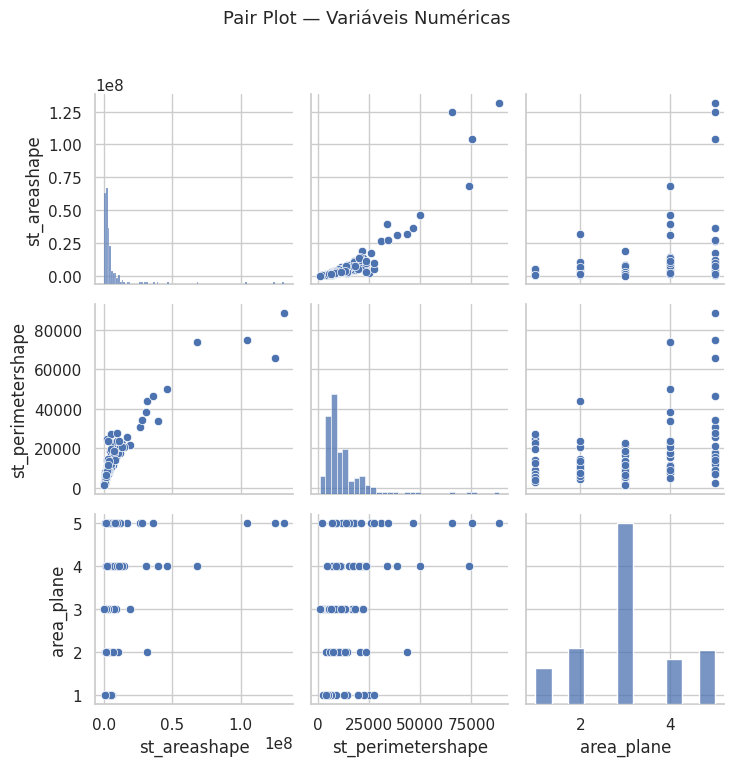

In [ ]:
# Pair plot das variáveis numéricas
sns.pairplot(df[['st_areashape', 'st_perimetershape', 'area_plane']])
plt.suptitle('Pair Plot — Variáveis Numéricas', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Vemos mais claramente agora os outliers observando o gráfico colorido de área por perimetro das regiões de planejamento como madureira. Pelo scatter plot podemos notar uma clara relação onde quanto maior a área maior seu perimetro o que faz muito sentido.

###Correlação e Heatmap

In [ ]:
# Matriz de correlação
cols_num = ['area_plane', 'codra', 'cod_rp', 'st_areashape', 'st_perimetershape']
df_corr = df[cols_num]
df_corr.corr()

,area_plane,codra,cod_rp,st_areashape,st_perimetershape
area_plane,1.000000,0.657893,0.984973,0.365527,0.350630
codra,0.657893,1.000000,0.706919,0.174405,0.188685
cod_rp,0.984973,0.706919,1.000000,0.347301,0.322520
st_areashape,0.365527,0.174405,0.347301,1.000000,0.914626
st_perimetershape,0.350630,0.188685,0.322520,0.914626,1.000000


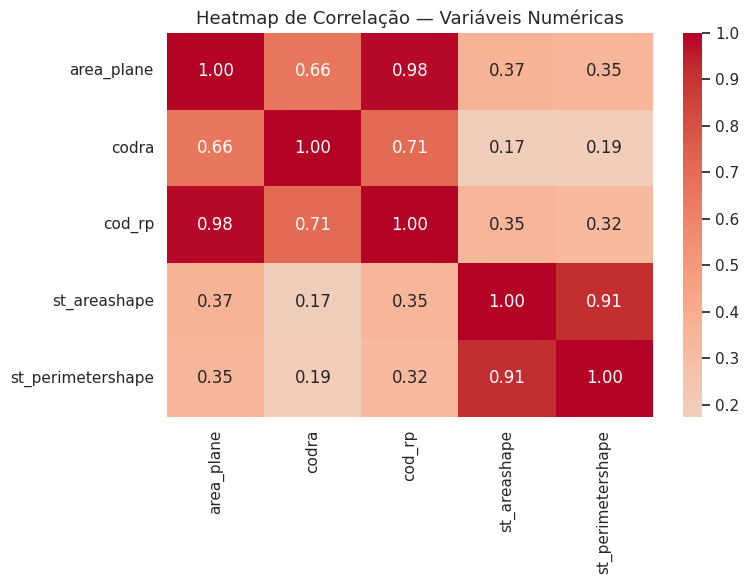

In [ ]:
# Heatmap de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap de Correlação — Variáveis Numéricas', fontsize=13)
plt.tight_layout()
plt.show()

O heatmap confirma a forte correlação entre área e perímetro que já haviamos notado. É interessante reparar que area_plane(zona de planejamento urbano) tem correlação moderada com a área geográfica, sugerindo que o zoneamento da cidade não foi definido de forma aleatória, bairros de zonas periféricas tendem a ser maiores.

###Conclusões


1.   O dataset possui 166 bairros, sem nenhum valor nulo em nenhuma coluna.
2.   As variáveis de área e perímetro apresentam alta assimetria (skew positivo), indicando que poucos bairros são muito grandes enquanto a maioria é menor.
3. A Região de Planejamento Madureira concentra o maior número de bairros (19), seguida de Zona Sul (18) e Méier (17).
4. Existe uma correlação forte e positiva entre área e perímetro dos bairros, o que é esperado geometricamente.
5. Bairros do Oeste da cidade (Santa Cruz, Guaratiba, Campo Grande) tendem a ter área média significativamente maior do que os bairros da Zona Sul e Centro.
6. A variável area_plane (zona de planejamento) apresenta correlação moderada com a área geográfica dos bairros.



